# Exoplanet Analysis Tools — 04: Joint transit+RV fit and derived parameters of TOI-3568 b

This final notebook performs the **joint MCMC fit** of the TESS transits and the
MAROON-X + SPIRou radial velocities — the analysis that constrains all planet parameters
simultaneously — and derives the physical parameters of TOI-3568 b, updating the
system parameters JSON file created in notebook 01.

In [1]:
%matplotlib inline
import glob, os, shutil
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from exoplanet_analysis import fitlib, rvutils, priorslib, systemlib

from exoplanet_analysis import datasets
# Download the tutorial data on first run (from the shared Google Drive
# folder). If already present under notebooks/data/, nothing is downloaded.
datasets.ensure("TOI-3568")
DATA = "data/TOI-3568/"
os.makedirs("outputs", exist_ok=True)
priors_file = "outputs/TOI-3568_joint.pars"
shutil.copyfile(DATA + "TOI-3568.pars", priors_file)

Dataset 'TOI-3568' already present at /home/claude/ExoplanetAnalysisTools/notebooks/data/TOI-3568


'outputs/TOI-3568_joint.pars'

## 1. Load photometry and RVs

We reuse the same data-preparation steps as notebooks 02 and 03.

In [2]:
def load_tess_lc(fitsfile, to_bjd=True):
    """Load a TESS light curve FITS file, returning (time, flux, fluxerr)."""
    d = fits.getdata(fitsfile, 1)
    keep = np.isfinite(d["TIME"]) & np.isfinite(d["FLUX"]) & np.isfinite(d["FLUX_ERR"])
    keep &= (d["QUALITY"] == 0)
    t = d["TIME"][keep].astype(float)
    if to_bjd:
        t = t + 2457000.0
    return t, d["FLUX"][keep].astype(float), d["FLUX_ERR"][keep].astype(float)

def select_transit_windows(t, f, ef, per, tc, window=0.25, min_pts=10, bin_to=None):
    """Split a light curve into normalized windows around each predicted transit."""
    e_min, e_max = int(np.ceil((t.min() - tc) / per)), int(np.floor((t.max() - tc) / per))
    times, fluxes, fluxerrs = [], [], []
    for e in range(e_min, e_max + 1):
        t_tr = tc + e * per
        m = np.abs(t - t_tr) < window
        if np.sum(m) < min_pts:
            continue
        wt, wf, we = t[m], f[m], ef[m]
        oot = np.abs(wt - t_tr) > 0.5 * window
        norm = np.median(wf[oot]) if np.sum(oot) > 3 else np.median(wf)
        wf, we = wf / norm, we / norm
        if bin_to is not None:
            wt, wf, we = fitlib.bin_data(wt, wf, we, median=False, binsize=bin_to)
            ok = np.isfinite(wf) & np.isfinite(we)
            wt, wf, we = wt[ok], wf[ok], we[ok]
        times.append(wt); fluxes.append(wf); fluxerrs.append(we)
    return times, fluxes, fluxerrs

per0, tc0 = 4.4178490108, 2459799.3828418534
times, fluxes, fluxerrs = [], [], []
for lc in sorted(glob.glob(DATA + "corrected_lc*.fits")):
    t, fl, ef = load_tess_lc(lc)
    bin_to = 10.0 / 60.0 / 24.0 if np.median(np.diff(t)) * 24 * 60 < 5 else None
    wt, wf, we = select_transit_windows(t, fl, ef, per0, tc0, bin_to=bin_to)
    times += wt; fluxes += wf; fluxerrs += we

rv_files = [DATA + "TOI-3568_maroon-x_blue.rdb", DATA + "TOI-3568_maroon-x_red.rdb", DATA + "TOI-3568_spirou_binned.rdb"]
labels = ["MAROON-X blue", "MAROON-X red", "SPIRou (binned)"]
bjds, rvs, rverrs = [], [], []
for f in rv_files:
    bjd, rv, rverr = rvutils.read_rv_time_series(f, conv_factor=1000.)
    bjds.append(bjd); rvs.append(rv); rverrs.append(rverr)

print("photometry: {} transit windows, {} points".format(len(times), sum(len(x) for x in times)))
print("RVs: {} datasets, {} points".format(len(rvs), sum(len(x) for x in rvs)))

photometry: 19 transit windows, 1078 points
RVs: 3 datasets, 71 points


## 2. Joint MCMC fit

The joint fit reads both photometric and RV calibration priors
(`read_transit_rv_priors`), estimates all calibration coefficients
(`guess_calib_transit_rv`), refines with least squares (`fitTransits_and_RVs_ols`),
and samples the joint posterior (`fitTransitsAndRVsWithMCMC`). This maximizes the
information: the photometry constrains the geometry and ephemeris while the RVs
constrain the planet mass.

*As in notebook 02, increase `niter` for publication-quality posteriors.*

In [3]:
priors = fitlib.read_transit_rv_priors(priors_file, len(rvs), len(times), calib_polyorder=1, verbose=False)

posterior = fitlib.guess_calib_transit_rv(priors, times, fluxes, bjds, rvs,
                                          prior_type="FIXED", remove_transits=True,
                                          rv_prior_type="Normal", plot=False)
print("free parameters ({}):".format(len(posterior["theta"])), posterior["labels"])

posterior = fitlib.fitTransits_and_RVs_ols(times, fluxes, fluxerrs, bjds, rvs, rverrs, posterior,
                                           fix_eccentricity=True, calib_post_type="FIXED",
                                           rvcalib_post_type="Normal", calib_unc=0.01,
                                           verbose=False, plot=False)

median_rv (no prior model considered) =  -2.09
median_rv= -0.760143012651088
median_rv (no prior model considered) =  -1.71
median_rv= -0.12984628284661603
median_rv (no prior model considered) =  -97661.1037544854
median_rv= -97670.43726352761
free parameters (11): ['a_000', 'rp_000', 'inc_000', 'u0_000', 'u1_000', 'k_000', 'tc_000', 'per_000', 'rv_d00', 'rv_d01', 'rv_d02']
Free parameters before OLS fit:
a_000 = 13.5328445553
rp_000 = 0.0762261965
inc_000 = 89.5230363203
k_000 = 12.0213119413
tc_000 = 2459799.3828418534
per_000 = 4.4178490108
rv_d00 = -0.760143012651088
rv_d01 = -0.12984628284661603
rv_d02 = -97670.43726352761
Free parameters after OLS fit:
a_000 = 13.288724475000018
rp_000 = 0.0681711474602221
inc_000 = 88.99453216638061
u0_000 = 0.3387441639
u1_000 = 0.3080111186
k_000 = 11.966585715394057
tc_000 = 2459799.381650486
per_000 = 4.417904819490666
rv_d00 = -0.9996151783428462
rv_d01 = -1.4574970624782841
rv_d02 = -97666.70818849759


Free parameters before MCMC fit:
a_000 = 13.5328445553
rp_000 = 0.0762261965
inc_000 = 89.5230363203
u0_000 = 0.3387441639
u1_000 = 0.3080111186
k_000 = 12.0213119413
tc_000 = 2459799.3828418534
per_000 = 4.4178490108
rv_d00 = -0.9996151783428462
rv_d01 = -1.4574970624782841
rv_d02 = -97666.70818849759
initializing emcee sampler ...
Running MCMC ...
N_walkers= 32  ndim= 11


  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 2/1500 [00:00<01:31, 16.39it/s]

  0%|          | 4/1500 [00:00<01:30, 16.56it/s]

  0%|          | 6/1500 [00:00<01:30, 16.59it/s]

...

100%|█████████▉| 1494/1500 [01:10<00:00, 23.75it/s]

100%|█████████▉| 1497/1500 [01:10<00:00, 22.93it/s]

100%|██████████| 1500/1500 [01:10<00:00, 22.23it/s]

100%|██████████| 1500/1500 [01:10<00:00, 21.13it/s]

Obtaining best fit calibration parameters from pdfs ...
CALIBRATION Fit parameters:
----------------
Output CALIBRATION posterior:  calibration_posterior.pars
Obtaining best fit RV calibration parameters from pdfs ...
RV CALIBRATION Fit parameters:
rv_d00 = -0.9895916487709866 + 0.25102234665924195 - 0.2546098357008755
rv_d01 = -1.4757273114002831 + 0.32296270734833965 - 0.3637012435467273
rv_d02 = -97666.67251622099 + 5.231604424800025 - 5.926196051281295
----------------
Output RV CALIBRATION posterior:  calibration_posterior.pars
Obtaining best fit planet parameters from pdfs ...
----------------
PLANET 2 Fit parameters:
a_000 = 12.444904488970312 + 0.5589956373201606 - 0.9681047766541937
----------------
rp_000 = 0.06682991336559693 + 0.0030399927961552164 - 0.0031476733317927913
----------------
inc_000 = 89.17831327505017 + 1.243037112972786 - 1.2950927163955583
----------------
u0_000 = 0.6038806258833587 + 0.22239071212493589 - 0.24826022999192188
----------------
u1_000 = 0.50

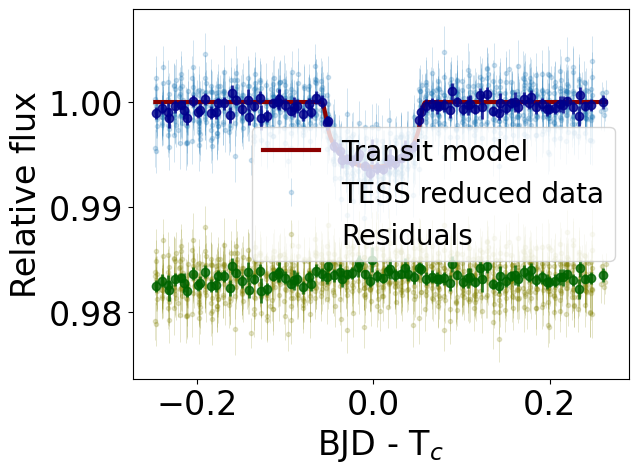

i= 0  rvcalib= -0.9895916487709866
i= 1  rvcalib= -1.4757273114002831
i= 2  rvcalib= -97666.67251622099
RMS of RV residuals: 3.47 m/s
Reduced chi-square (n=5, DOF=-3): -0.44


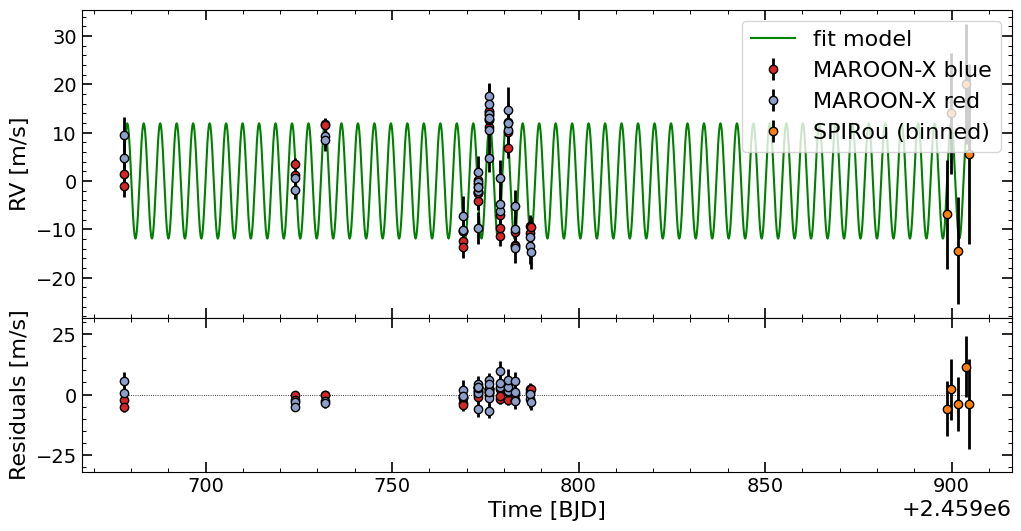

RMS of RV residuals: 3.47 m/s
Reduced chi-square (n=5, DOF=-3): -0.44


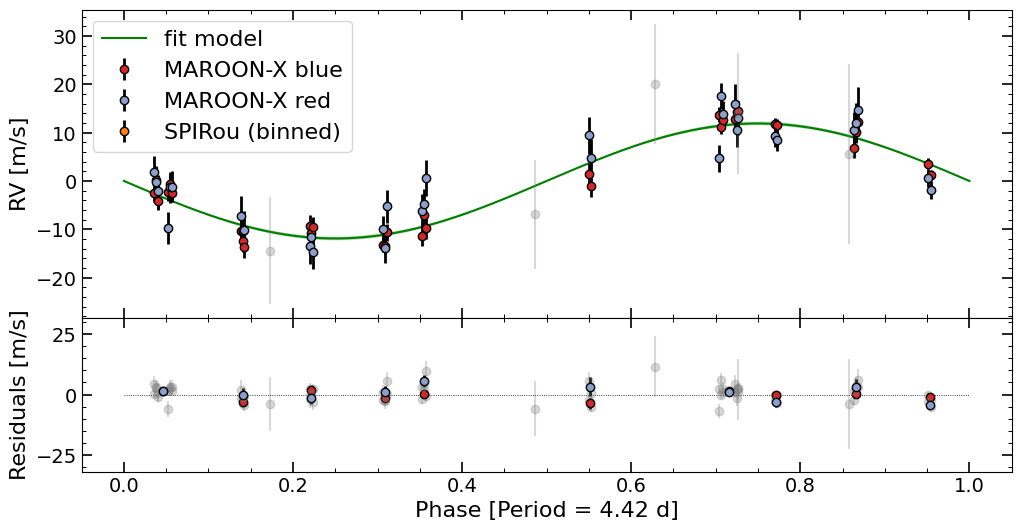

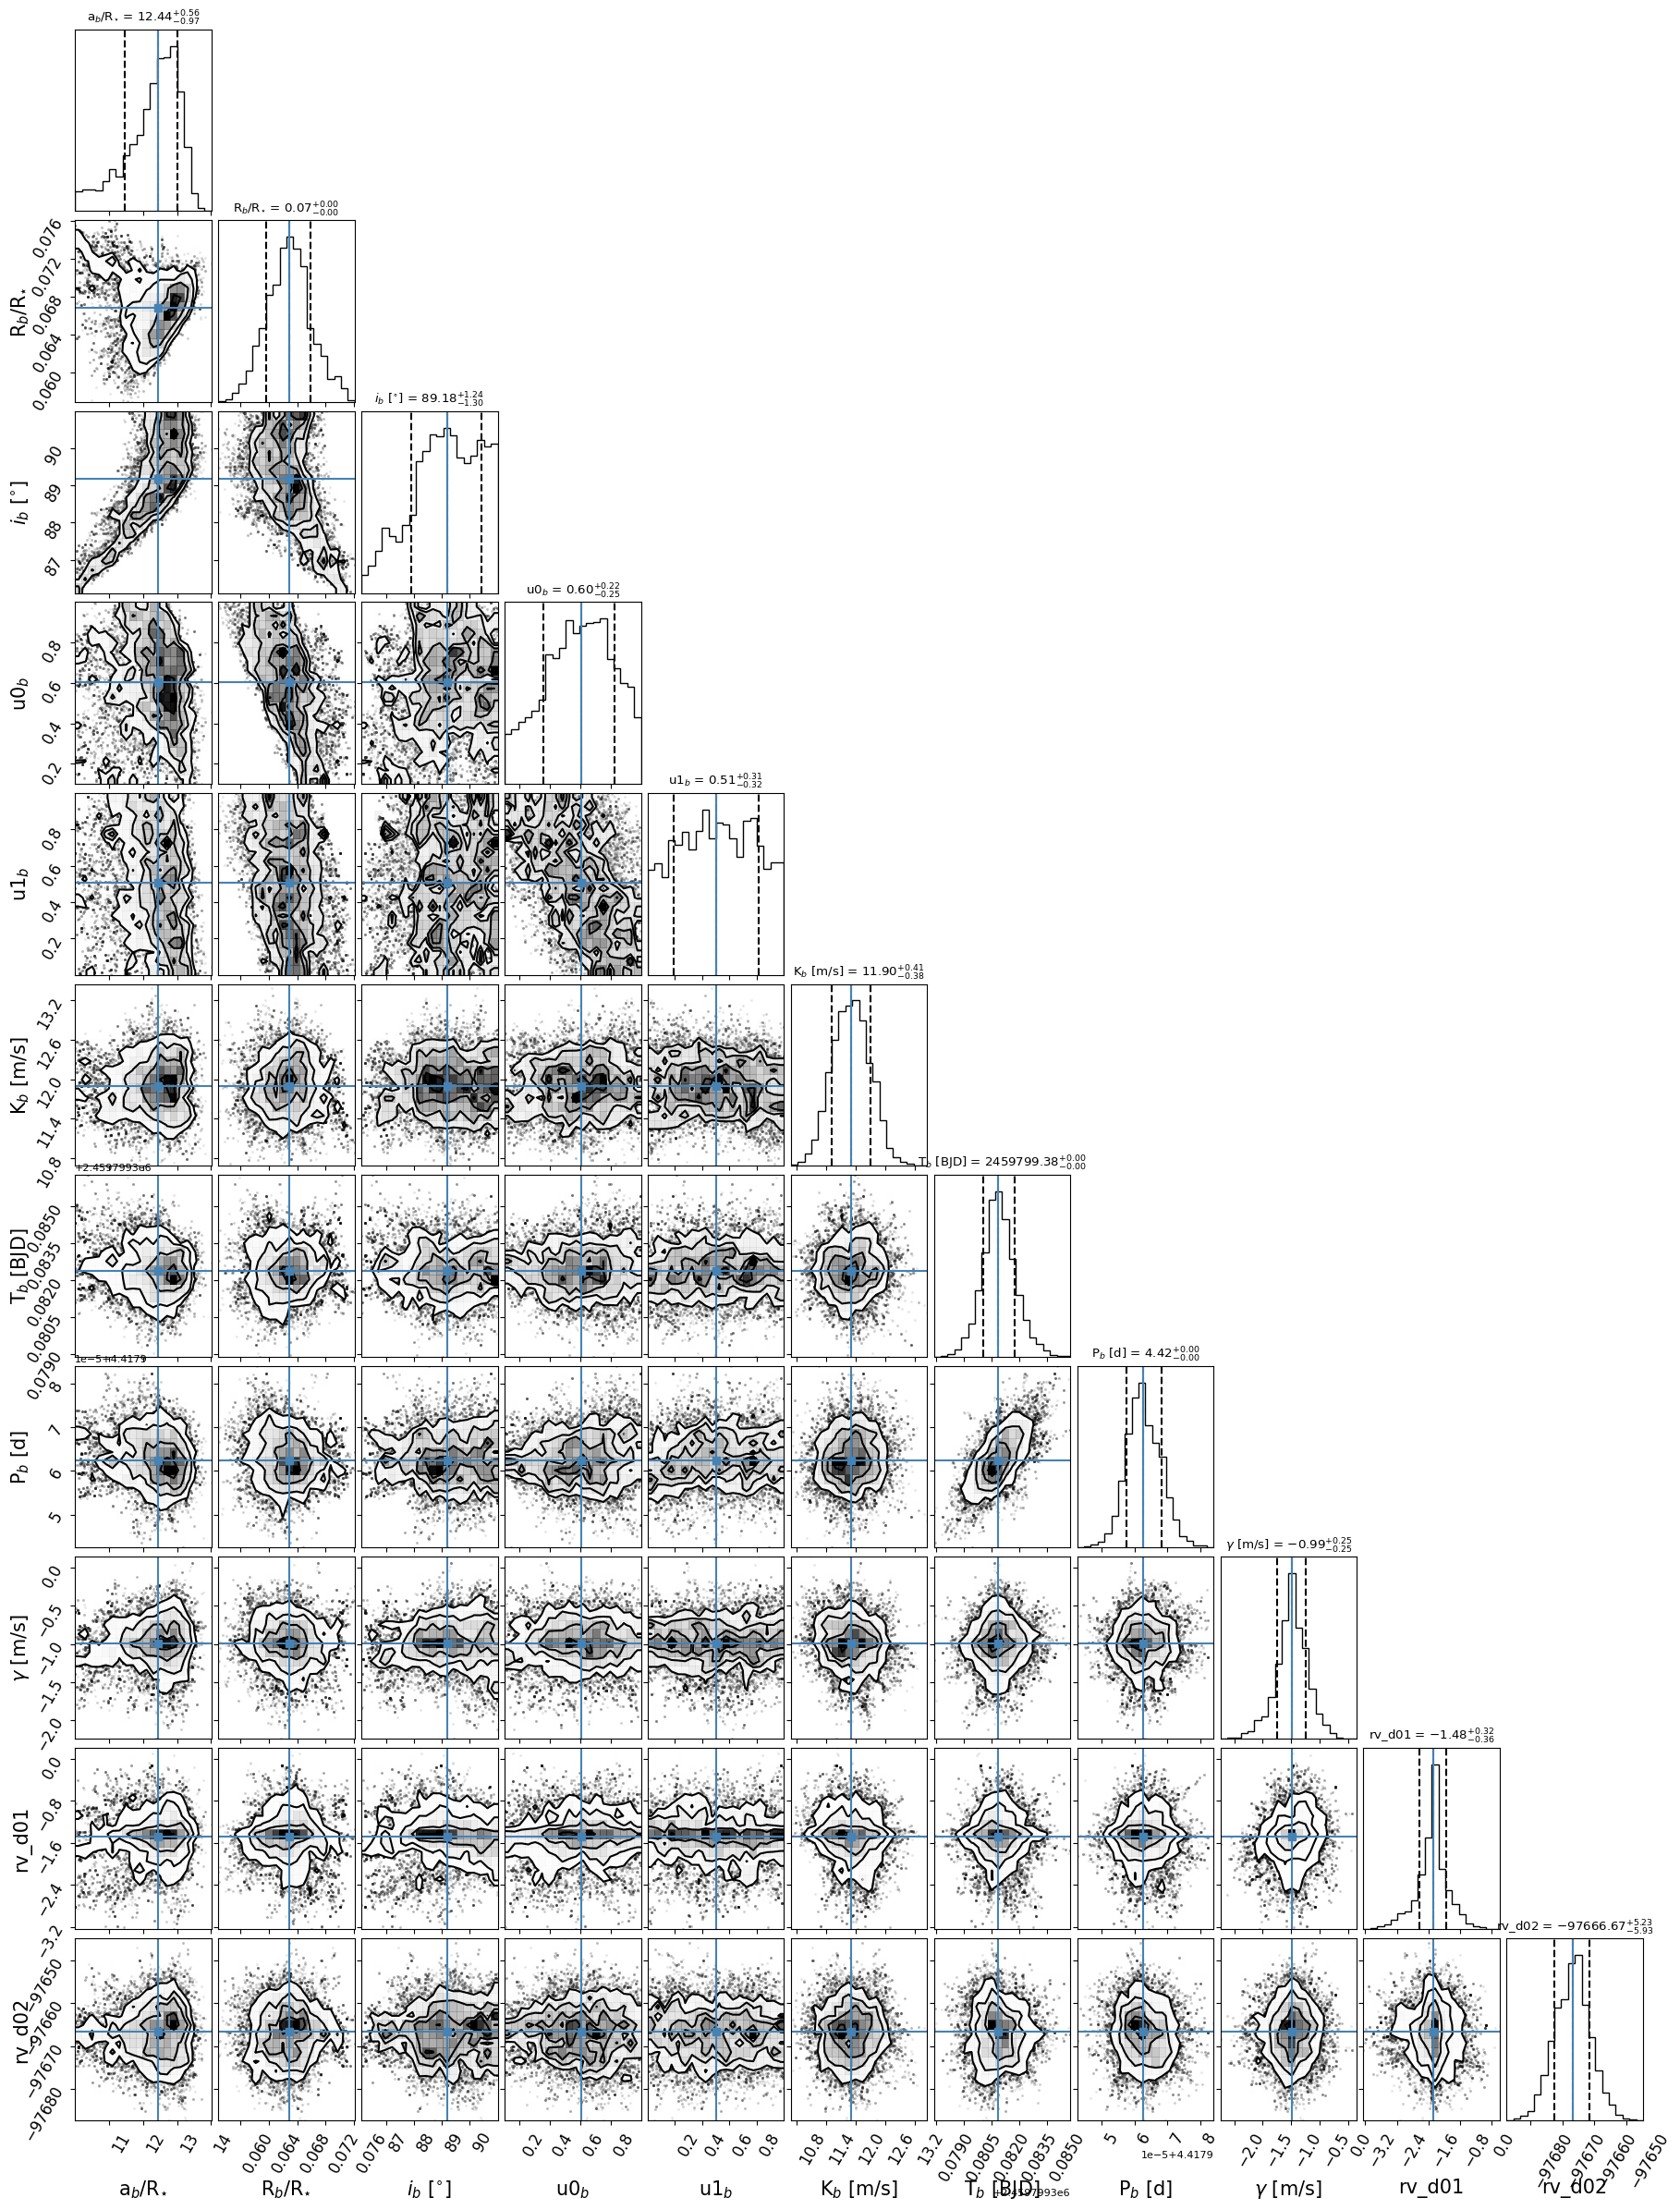

In [4]:
posterior = fitlib.fitTransitsAndRVsWithMCMC(times, fluxes, fluxerrs, bjds, rvs, rverrs, posterior,
                                             amp=1e-7, nwalkers=32, niter=1500, burnin=500,
                                             samples_filename="outputs/TOI-3568_joint_samples.h5",
                                             verbose=True, plot=True,
                                             rvdatalabels=labels, timelabel="BJD", plot_rv_bins=True)

## 3. Update the system parameters JSON and derive the physical parameters

We now merge the joint posterior into the system JSON created in notebook 01 and
compute the derived physical parameters (planet mass, radius, density, surface gravity,
semi-major axis, equilibrium temperature, transit duration) with full uncertainty
propagation. The same operations are available from the command line with the
`system_params` tool.

In [5]:
system_file = "outputs/TOI-3568_system.json"
if not os.path.exists(system_file):
    raise RuntimeError("Please run notebook 01 first to create the system JSON file.")

system = systemlib.load_system(system_file)
system = systemlib.update_system_from_posterior(system, "outputs/TOI-3568_joint_posterior.pars")
system = systemlib.compute_derived_parameters(system)
systemlib.save_system(system, "outputs/TOI-3568_system_final.json")

planet = system["planet b"]
def fmt(entry):
    if entry is None or entry[0] is None: return "-"
    val = entry[0]
    # use fixed notation for large values (e.g. BJD) to avoid 2.46e+06
    prec = ".4f" if abs(val) >= 1e5 else ".4g"
    if len(entry) > 1 and entry[1] is not None:
        return ("{:" + prec + "} +/- {:.2g}").format(val, entry[1])
    return ("{:" + prec + "}").format(val)

rows = [
    ("Orbital period [d]",            fmt(planet["orbital_period_days"]),   "4.417965 +/- 0.000005"),
    ("Transit time [BJD]",            fmt(planet["transit_time_bjd"]),      "2459799.3821 +/- 0.0009"),
    ("Rp/Rstar",                      fmt(planet["radius_rstar"]),          "0.0685 +/- 0.0025"),
    ("a/Rstar",                       fmt(planet["orbital_sma_rstar"]),     "13.19 +/- 0.35"),
    ("Inclination [deg]",             fmt(planet["orbital_inc"]),           "89.5 +/- 0.6"),
    ("K [m/s]",                       fmt(planet["rv_semi_amplitude"]),     "11.9 +/- 1.7"),
    ("Planet radius [R_Earth]",       fmt(planet["radius_earth"]),          "5.30 +/- 0.27"),
    ("Planet mass [M_Earth]",         fmt(planet["mass_earth"]),            "26.4 +/- 5.0"),
    ("Density [g/cm^3]",              fmt(planet["density_cgs"]),           "0.98 +/- 0.29"),
    ("Semi-major axis [au]",          fmt(planet["orbital_sma_au"]),        "0.0485 +/- 0.0004"),
    ("Equilibrium temperature [K]",   fmt(planet["equilibrium_temperature"]), "~ 900"),
]
print("{:32s} {:26s} {}".format("Parameter", "This notebook", "Martioli et al. (2024)"))
print("-" * 92)
for name, mine, paper in rows:
    print("{:32s} {:26s} {}".format(name, mine, paper))

Parameter                        This notebook              Martioli et al. (2024)
--------------------------------------------------------------------------------------------
Orbital period [d]               4.418 +/- 5.2e-06          4.417965 +/- 0.000005
Transit time [BJD]               2459799.3824 +/- 0.00086   2459799.3821 +/- 0.0009
Rp/Rstar                         0.06683 +/- 0.0031         0.0685 +/- 0.0025
a/Rstar                          12.44 +/- 0.76             13.19 +/- 0.35
Inclination [deg]                89.18 +/- 1.3              89.5 +/- 0.6
K [m/s]                          11.9 +/- 0.39              11.9 +/- 1.7
Planet radius [R_Earth]          5.252 +/- 0.26             5.30 +/- 0.27
Planet mass [M_Earth]            25.79 +/- 0.97             26.4 +/- 5.0
Density [g/cm^3]                 0.9817 +/- 0.15            0.98 +/- 0.29
Semi-major axis [au]             0.04165 +/- 0.0027         0.0485 +/- 0.0004
Equilibrium temperature [K]      898 +/- 13                 

/usr/local/lib/python3.12/dist-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


*Note: the values obtained here use short MCMC chains and simplified calibration
(fixed photometric baselines, no GP activity model, no RV jitter terms), so the
uncertainties are underestimated relative to the published analysis — the purpose of
this notebook is to demonstrate the workflow. See `transit_rv_fit -h` for the
full-featured command-line pipeline including GP activity modeling.*

## 5. The final system parameters file

The complete state of the system — fitted, fixed, and derived parameters —
now lives in a single JSON file: 

In [6]:
print(open("outputs/TOI-3568_system_final.json").read())

{
    "_format": "exoplanet_analysis system parameters",
    "_schema_version": "1.1",
    "_comment": "Planetary system parameters. Format: [value, 1-sigma uncertainty] or [value, err_minus, err_plus] (posteriors), or a dict {'value','error','prior','min','max'} for full prior control. null = unknown/not applicable.",
    "_reference": null,
    "system_name": "TOI-3568",
    "components": [
        "star A",
        "planet b"
    ],
    "star A": {
        "name": "TOI-3568",
        "object_type": "star",
        "_comment_stellar": "Fundamental stellar parameters: teff [K], mass [Msun], radius [Rsun], density [g/cm^3]",
        "teff": [
            4960.0,
            49.0
        ],
        "logg": [
            null,
            null
        ],
        "mass": [
            0.776,
            0.021
        ],
        "radius": [
            0.719,
            0.013
        ],
        "density": [
            null,
            null
        ],
        "metallicity": [
           